In [3]:
import pandas as pd
df = pd.read_csv("clusters/BlaBla0506_110304-Song-06_clusters_metadata.csv")

In [4]:
df.columns

Index(['feature_idx', 'chunk_idx', 'window_idx', 'global_start_time',
       'global_end_time', 'cluster'],
      dtype='str')

In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install rapidfuzz

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 14.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [26]:
import os
import glob
import random
import pandas as pd
from itertools import combinations
from joblib import Parallel, delayed
from rapidfuzz.distance import Levenshtein

def parse_call_type(filename):
    basename = os.path.basename(filename)
    parts = basename.split('-')
    return parts[1].strip()[:2]

def collapse_duplicates(seq):
    if not seq: return []
    res = [seq[0]]
    for item in seq[1:]:
        if item != res[-1]: res.append(item)
    return res

def compute_pair(pair):
    (d1, d2) = pair
    # Convert integer clusters to characters for fast C-level string distance
    str1 = "".join([chr(c + 33) for c in d1['sequence']])
    str2 = "".join([chr(c + 33) for c in d2['sequence']])
    
    raw_dist = Levenshtein.distance(str1, str2)
    max_len = max(len(str1), len(str2))
    norm_dist = raw_dist / max_len if max_len > 0 else 0.0
    
    is_same = (d1['call_type'] == d2['call_type'])
    return {
        'file_1': d1['file'],
        'file_2': d2['file'],
        'call_type_1': d1['call_type'],
        'call_type_2': d2['call_type'],
        'category': "Intra-Call Type (Similar)" if is_same else "Inter-Call Type (Different)",
        'raw_distance': raw_dist,
        'normalized_distance': norm_dist
    }

def process_sampled_clusters(directory_path, sample_size=100, seed=42, n_jobs=4):
    all_files = glob.glob(os.path.join(directory_path, "*_clusters_metadata.csv"))
    
    random.seed(seed)
    sampled_files = random.sample(all_files, min(sample_size, len(all_files)))
    print(f"Sampled {len(sampled_files)} files out of {len(all_files)} total matching files.")

    data = []
    for f in sampled_files:
        call_type = parse_call_type(f)
        if not call_type or call_type.lower() == "song":
            continue
        
        df = pd.read_csv(f)
        if df.empty or 'cluster' not in df.columns:
            continue
            
        df = df.sort_values(by=['global_start_time', 'feature_idx'])
        seq = collapse_duplicates(df['cluster'].tolist())
        
        if len(seq) > 0:
            data.append({'file': os.path.basename(f), 'call_type': call_type, 'sequence': seq})

    all_pairs = list(combinations(data, 2))
    print(f"Computing Levenshtein distances for {len(all_pairs):,} pairs...")
    
    results = Parallel(n_jobs=n_jobs)(delayed(compute_pair)(p) for p in all_pairs)
    
    return pd.DataFrame(data), pd.DataFrame(results)

df_meta, df_pairs = process_sampled_clusters("clusters", sample_size=100, seed=42)

Sampled 100 files out of 1312 total matching files.
Computing Levenshtein distances for 4,950 pairs...


C:\Users\oscar\AppData\Local\Temp\ipykernel_12196\269544885.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


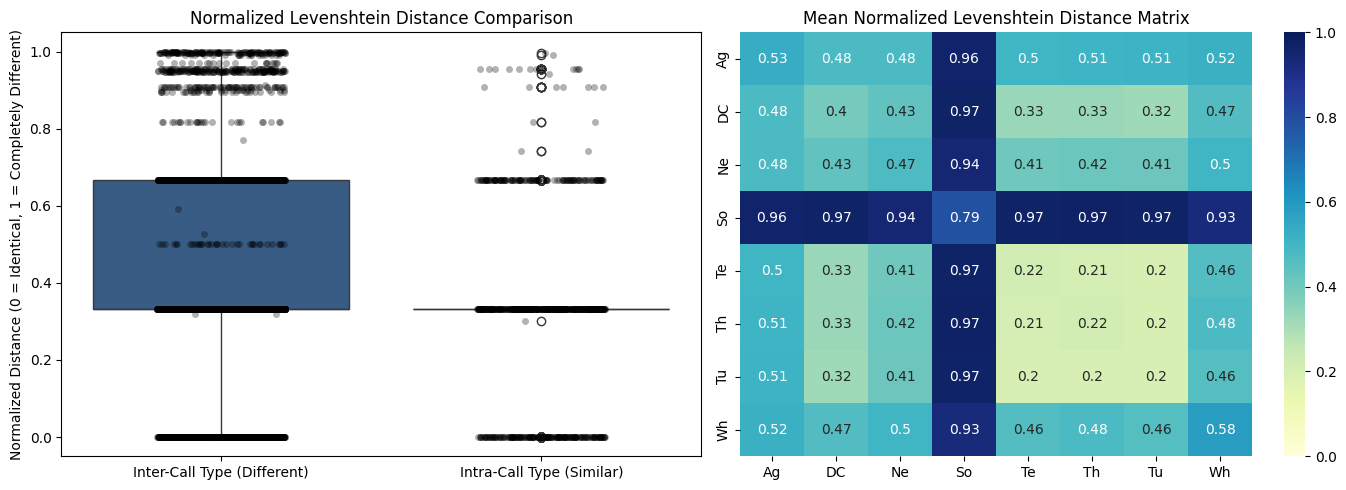

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_pairs, x="category", y="normalized_distance", 
    palette=["#2b5c8f", "#d95f02"], ax=axes[0]
)
sns.stripplot(
    data=df_pairs, x="category", y="normalized_distance", 
    color="black", alpha=0.3, jitter=0.2, ax=axes[0]
)
axes[0].set_title("Normalized Levenshtein Distance Comparison")
axes[0].set_ylabel("Normalized Distance (0 = Identical, 1 = Completely Different)")
axes[0].set_xlabel("")

# Plot 2: Inter-Call Type Heatmap Matrix
call_types = sorted(df_meta['call_type'].unique())
matrix = pd.DataFrame(index=call_types, columns=call_types, dtype=float)

for t1 in call_types:
    for t2 in call_types:
        subset = df_pairs[
            ((df_pairs['call_type_1'] == t1) & (df_pairs['call_type_2'] == t2)) |
            ((df_pairs['call_type_1'] == t2) & (df_pairs['call_type_2'] == t1))
        ]
        if not subset.empty:
            matrix.loc[t1, t2] = subset['normalized_distance'].mean()
        elif t1 == t2:
            matrix.loc[t1, t2] = 0.0

sns.heatmap(matrix, annot=True, cmap="YlGnBu", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Mean Normalized Levenshtein Distance Matrix")

plt.tight_layout()
plt.savefig("levenshtein_clusters_sample.png", dpi=300)
plt.show()

In [19]:
import os
import glob
import random
import pandas as pd
from itertools import combinations
from rapidfuzz.distance import Levenshtein

def find_cluster_files(base_dir="cluster"):
    abs_path = os.path.abspath(base_dir)
    files = glob.glob(os.path.join(abs_path, "**", "*_clusters_metadata.csv"), recursive=True)
    if not files:
        files = glob.glob(os.path.join(abs_path, "**", "*.csv"), recursive=True)
        files = [f for f in files if "clusters" in f.lower() or "metadata" in f.lower()]
    return files

def parse_call_type(filename):
    basename = os.path.basename(filename)
    parts = basename.split('-')
    return parts[1].strip() if len(parts) >= 2 else None

def collapse_duplicates(seq):
    if not seq: return []
    res = [seq[0]]
    for item in seq[1:]:
        if item != res[-1]: res.append(item)
    return res

def clusters_to_string(seq):
    return "".join([chr(int(c) + 33) for c in seq if pd.notna(c)])

# --- EXECUTION ---
all_files = find_cluster_files("cluster")

if len(all_files) > 0:
    random.seed(42)
    sampled_files = random.sample(all_files, min(100, len(all_files)))
    print(f"Processing sample of {len(sampled_files)} files...")

    data = []
    for f in sampled_files:
        call_type = parse_call_type(f)
        if not call_type or call_type.lower() == "song":
            continue
        
        df = pd.read_csv(f)
        if df.empty or 'cluster' not in df.columns:
            continue
            
        df = df.sort_values(by=['global_start_time', 'feature_idx'])
        raw_seq = df['cluster'].dropna().tolist()
        seq = collapse_duplicates(raw_seq)
        
        if len(seq) > 0:
            data.append({
                'file': os.path.basename(f), 
                'call_type': call_type, 
                'sequence': seq,
                'char_str': clusters_to_string(seq)
            })

    print(f"Loaded {len(data)} valid non-song files.")

    all_pairs = list(combinations(data, 2))
    print(f"Computing raw Levenshtein distances for {len(all_pairs):,} pairs...")
    
    results = []
    for d1, d2 in all_pairs:
        raw_dist = Levenshtein.distance(d1['char_str'], d2['char_str'])
        is_same = (d1['call_type'] == d2['call_type'])
        
        results.append({
            'file_1': d1['file'],
            'file_2': d2['file'],
            'call_type_1': d1['call_type'],
            'call_type_2': d2['call_type'],
            'category': "Intra-Call Type (Similar)" if is_same else "Inter-Call Type (Different)",
            'raw_distance': raw_dist
        })

    df_meta = pd.DataFrame(data)
    df_pairs = pd.DataFrame(results)
    print("Computation complete.")

C:\Users\oscar\AppData\Local\Temp\ipykernel_12196\1491086193.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


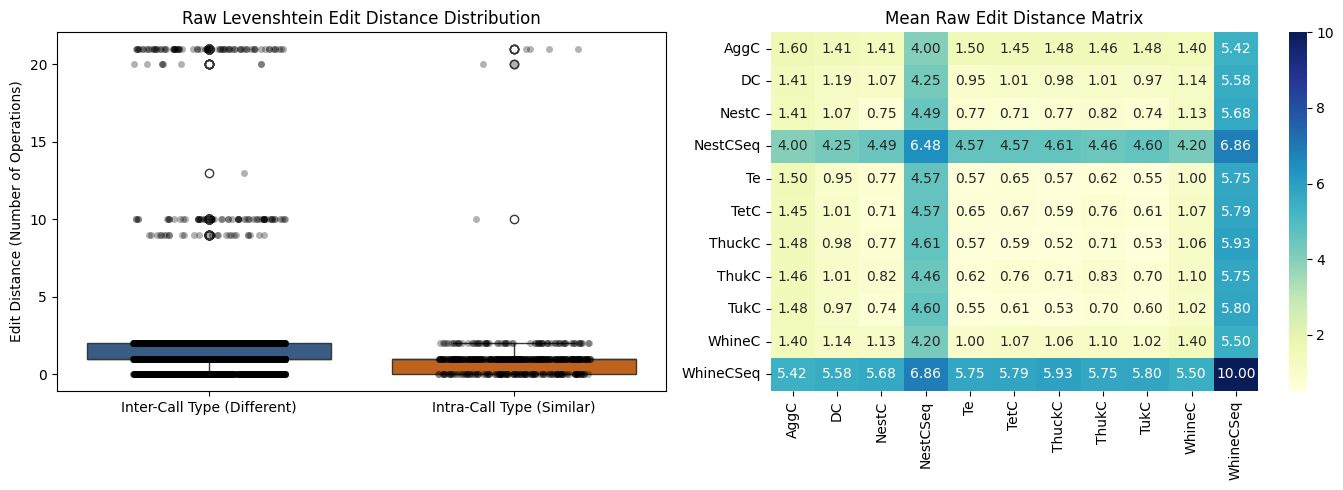

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot with jittered integer points
sns.boxplot(
    data=df_pairs, x="category", y="raw_distance", 
    palette=["#2b5c8f", "#d95f02"], ax=axes[0]
)
sns.stripplot(
    data=df_pairs, x="category", y="raw_distance", 
    color="black", alpha=0.3, jitter=0.25, ax=axes[0]
)
axes[0].set_title("Raw Levenshtein Edit Distance Distribution")
axes[0].set_ylabel("Edit Distance (Number of Operations)")
axes[0].set_xlabel("")

# Plot 2: Mean Raw Distance Heatmap Matrix
call_types = sorted(df_meta['call_type'].unique())
matrix = pd.DataFrame(index=call_types, columns=call_types, dtype=float)

for t1 in call_types:
    for t2 in call_types:
        subset = df_pairs[
            ((df_pairs['call_type_1'] == t1) & (df_pairs['call_type_2'] == t2)) |
            ((df_pairs['call_type_1'] == t2) & (df_pairs['call_type_2'] == t1))
        ]
        if not subset.empty:
            matrix.loc[t1, t2] = subset['raw_distance'].mean()
        elif t1 == t2:
            matrix.loc[t1, t2] = 0.0

sns.heatmap(matrix, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Mean Raw Edit Distance Matrix")

plt.tight_layout()
plt.savefig("raw_levenshtein_clusters.png", dpi=300)
plt.show()